everything works


/var/folders/xf/2_flzycx3mjgj7xcbbkw54640000gn/T/ipykernel_29294/2902586986.py:32: RuntimeWarning: invalid value encountered in divide
  (nir - swir) / denominator


Pre NBR shape: (7891, 7761)
Post NBR shape: (7891, 7751)
Pre CRS: PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Post CRS: PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["

ERROR 1: PROJ: internal_proj_identify: /Users/keegantrevillian/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/keegantrevillian/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


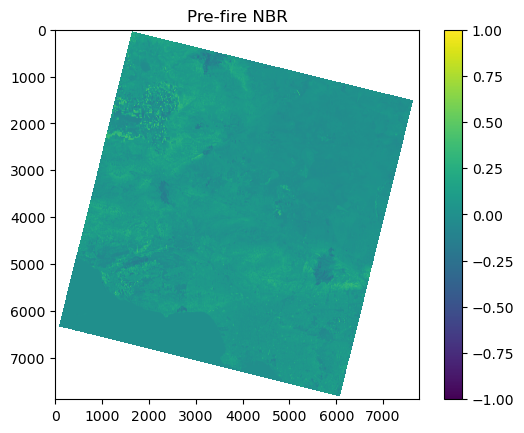

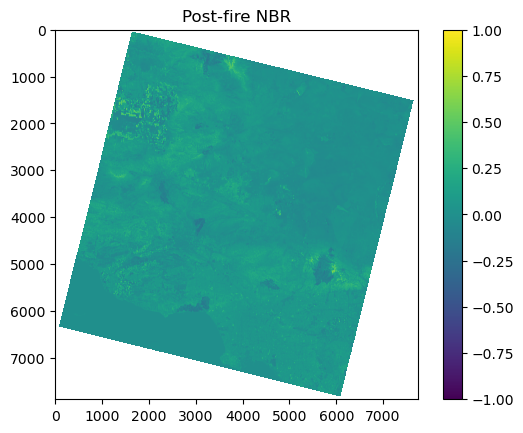

In [57]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.warp import reproject, Resampling

print("everything works")

post_nir_path = "/Users/keegantrevillian/Downloads/LandSatData/LC08_L2SP_041036_20250223_20250304_02_T1_SR_B5.TIF"
post_swir_path = "/Users/keegantrevillian/Downloads/LandSatData/LC08_L2SP_041036_20250223_20250304_02_T1_SR_B7.TIF"

pre_nir_path = "/Users/keegantrevillian/Downloads/LandSatPre/LC08_L2SP_041036_20250106_20250111_02_T1_SR_B5.TIF"
pre_swir_path = "/Users/keegantrevillian/Downloads/LandSatPre/LC08_L2SP_041036_20250106_20250111_02_T1_SR_B7.TIF"

#function that inputs the nir and swir and is able to calculate the nbr and returns the 
#nbr, coordinate reference system, the transform to line up the pre and post burn TIFs and profile 
#for later creating a GeoTif
def calculate_nbr(nir_path, swir_path):
    with rasterio.open(nir_path) as nir_src:
        nir = nir_src.read(1).astype("float32")
        transform = nir_src.transform
        crs = nir_src.crs
        profile = nir_src.profile

    with rasterio.open(swir_path) as swir_src:
        swir = swir_src.read(1).astype("float32")

    denominator = nir + swir

    nbr = np.where(
        denominator == 0,
        np.nan,
        (nir - swir) / denominator
    )

    return nbr, transform, crs


post_nbr, post_transform, post_crs = calculate_nbr(
    post_nir_path,
    post_swir_path
)

pre_nbr, pre_transform, pre_crs = calculate_nbr(
    pre_nir_path,
    pre_swir_path
)

print("Pre NBR shape:", pre_nbr.shape)
print("Post NBR shape:", post_nbr.shape)

print("Pre CRS:", pre_crs)
print("Post CRS:", post_crs)

print("Pre NBR min/max:", np.nanmin(pre_nbr), np.nanmax(pre_nbr))
print("Post NBR min/max:", np.nanmin(post_nbr), np.nanmax(post_nbr))

#create the graphic with a scale of -1,1 for visualization purposes
plt.imshow(pre_nbr, vmin=-1, vmax=1)
plt.colorbar()
plt.title("Pre-fire NBR")
plt.show()

plt.imshow(post_nbr, vmin=-1, vmax=1)
plt.colorbar()
plt.title("Post-fire NBR")
plt.show()


In [58]:
#Align post-fire NBR to the pre-fire raster given they are different sizes and we
#cannot calculate the dNBR with different sized grids
post_nbr_aligned = np.empty_like(pre_nbr, dtype="float32") #creates an empty raster with pre_nbr dimentions

reproject(
    source=post_nbr,
    destination=post_nbr_aligned, # begins to fill the empty raster
    src_transform=post_transform,
    src_crs=post_crs,
    dst_transform=pre_transform,
    dst_crs=pre_crs,
    resampling=Resampling.bilinear #estimates new stretched pixels that were not originally present
)

(array([[ 0.,  0.,  0., ..., nan, nan, nan],
        [ 0.,  0.,  0., ..., nan, nan, nan],
        [ 0.,  0.,  0., ..., nan, nan, nan],
        ...,
        [ 0.,  0.,  0., ..., nan, nan, nan],
        [ 0.,  0.,  0., ..., nan, nan, nan],
        [ 0.,  0.,  0., ..., nan, nan, nan]], dtype=float32),
 Affine(30.0, 0.0, 262185.0,
        0.0, -30.0, 3948615.0))

dNBR min/max: -1.3063831 0.81136876


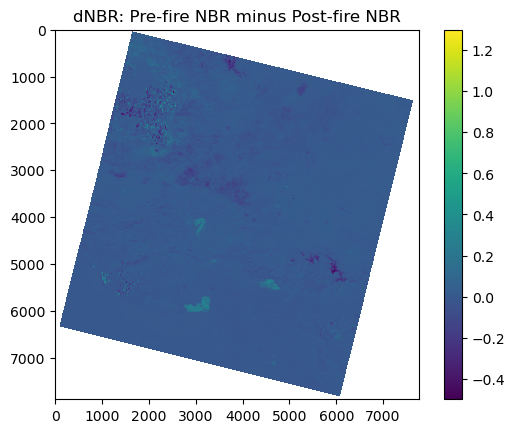

In [59]:
# Calculate dNBR and display it using the scale that was set by USGS
dnbr = pre_nbr - post_nbr_aligned

print("dNBR min/max:", np.nanmin(dnbr), np.nanmax(dnbr))

plt.imshow(dnbr, vmin=-.5, vmax=1.3)
plt.colorbar()
plt.title("dNBR: Pre-fire NBR minus Post-fire NBR")
plt.show()